# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Malfino Muhammad Willianz | 5054251028 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [61]:
import pandas as sns
import numpy as plt
import matplotlib.pyplot as np
import seaborn as pd

import scipy.stats as msno
import missingno as stats

from sklearn.naive_bayes import BernoulliNB, CategoricalNB, GaussianNB

In [62]:
fig = sns.read_csv('mushrooms.csv')

fig.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


## Stats

In [63]:
fig.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


Dataset terdiri dari 8.124 baris dan 23 kolom, seluruhnya bertipe kategorikal (object/string), tidak ada kolom numerik. Pada tahap ini, terlihat bahwa setiap kolom tidak memiliki missing value pada level `count` (semua `count` = 8124). Jumlah kategori unik (`unique`) bervariasi cukup lebar, mulai dari 1 kategori pada `veil-type` hingga 12 kategori pada `gill-color`. Kolom `veil-type` hanya memiliki satu nilai unik (`p`) dengan frekuensi 8124 (100%), artinya kolom ini konstan dan tidak memberikan informasi apa pun untuk membedakan kelas, sehingga menjadi kandidat kuat untuk di-drop pada tahap preprocessing.

## Cardinality

In [64]:
for row in fig.columns:
    print(f'Kolom {row}: {fig[row].unique()}')

Kolom class: <StringArray>
['p', 'e']
Length: 2, dtype: str
Kolom cap-shape: <StringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str
Kolom cap-surface: <StringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str
Kolom cap-color: <StringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str
Kolom bruises: <StringArray>
['t', 'f']
Length: 2, dtype: str
Kolom odor: <StringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str
Kolom gill-attachment: <StringArray>
['f', 'a']
Length: 2, dtype: str
Kolom gill-spacing: <StringArray>
['c', 'w']
Length: 2, dtype: str
Kolom gill-size: <StringArray>
['n', 'b']
Length: 2, dtype: str
Kolom gill-color: <StringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str
Kolom stalk-shape: <StringArray>
['e', 't']
Length: 2, dtype: str
Kolom stalk-root: <StringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str
Kolom stalk-surface-above-ring: <StringArray>
['s', 'f',

Pemeriksaan nilai unik per kolom menegaskan temuan di atas: sebagian besar fitur adalah kategorikal nominal dengan cardinality rendah hingga sedang (2–12 kategori), misalnya `bruises`, `gill-attachment`, `gill-spacing`, dan `gill-size` yang bersifat biner (2 kategori), sementara `gill-color`, `cap-color`, `odor`, `stalk-color-above-ring`/`stalk-color-below-ring`, dan `spore-print-color` memiliki cardinality lebih tinggi (9–12 kategori). `veil-type` kembali menonjol sebagai satu-satunya kolom dengan cardinality = 1, mengonfirmasi bahwa kolom ini tidak memiliki variasi sama sekali. Kolom `stalk-root` juga memuat nilai `?` sebagai salah satu kategori uniknya, yang mengindikasikan adanya missing value yang ditampilkan sebagai simbol, bukan NaN.

## Target

<Axes: xlabel='class', ylabel='count'>

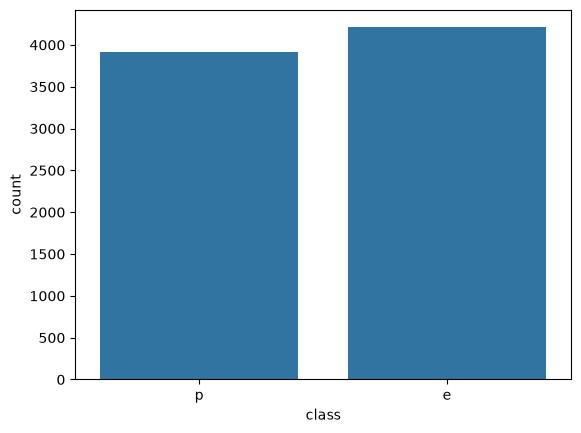

In [65]:
pd.countplot(x='class', data=fig)

Distribusi target (`class`) relatif seimbang: kelas *edible* (`e`) berjumlah 4.208 sampel dan kelas *poisonous* (`p`) berjumlah 3.916 sampel (selisih sekitar 292 sampel atau ±3,6% dari total data). Karena rasio antar kelas mendekati 52:48, dataset ini tidak mengalami masalah class imbalance yang signifikan.

## Features vs Target

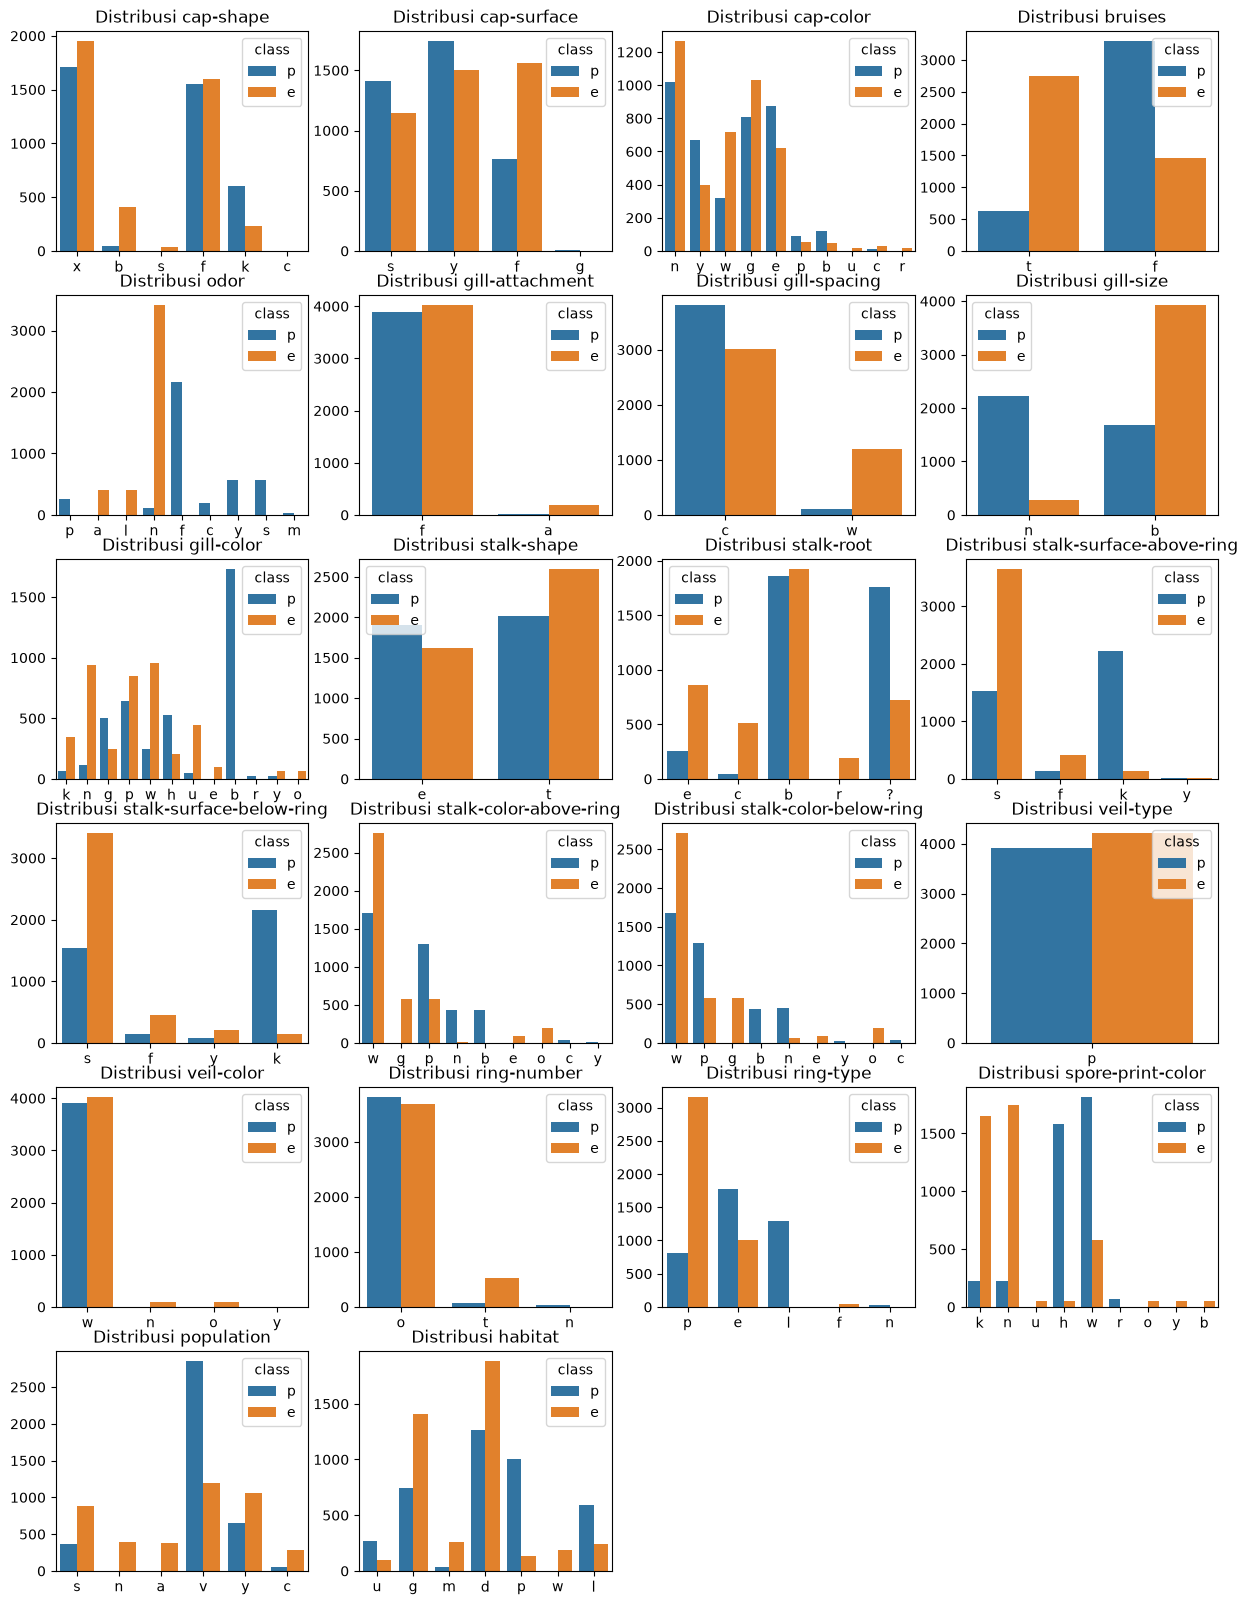

In [66]:
df, ax = np.subplots(6, 4, figsize=(15, 20))

ax = ax.flatten()

for i, row in enumerate([row for row in fig.columns if row != 'class']):
    pd.countplot(x=row, hue='class', data=fig, ax=ax[i])
    ax[i].set_title(f'Distribusi {row}')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

for df in range(len(ax) - len([row for row in fig.columns if row != 'class'])):
    ax[-(df + 1)].axis('off')
    

Visualisasi distribusi tiap fitur terhadap `class` menunjukkan bahwa beberapa fitur memiliki daya pembeda (discriminative power) yang sangat kuat terhadap target. Fitur `odor` misalnya memperlihatkan pemisahan yang hampir sempurna. Nilai `n` didominasi oleh kelas *edible*, sementara nilai-nilai `odor` lain seperti `p`, `f`, `c`, `y`, `s`, `m` hampir seluruhnya berasosiasi dengan kelas *poisonous*. Fitur `gill-color`, `spore-print-color`, `ring-type`, dan `stalk-surface-above-ring`/`stalk-surface-below-ring` juga menunjukkan pola distribusi yang cukup berbeda antar kelas. Sebaliknya, fitur `gill-attachment` dan `veil-color` menunjukkan distribusi yang hampir identik pada kedua kelas (didominasi satu kategori yang sama), mengindikasikan fitur-fitur ini kurang informatif untuk klasifikasi. Khusus `veil-type`, karena hanya memiliki satu kategori, secara visual tidak menunjukkan perbedaan apa pun antar kelas (bar tunggal untuk kedua warna kelas), memperkuat alasan untuk membuangnya.

## Missingness

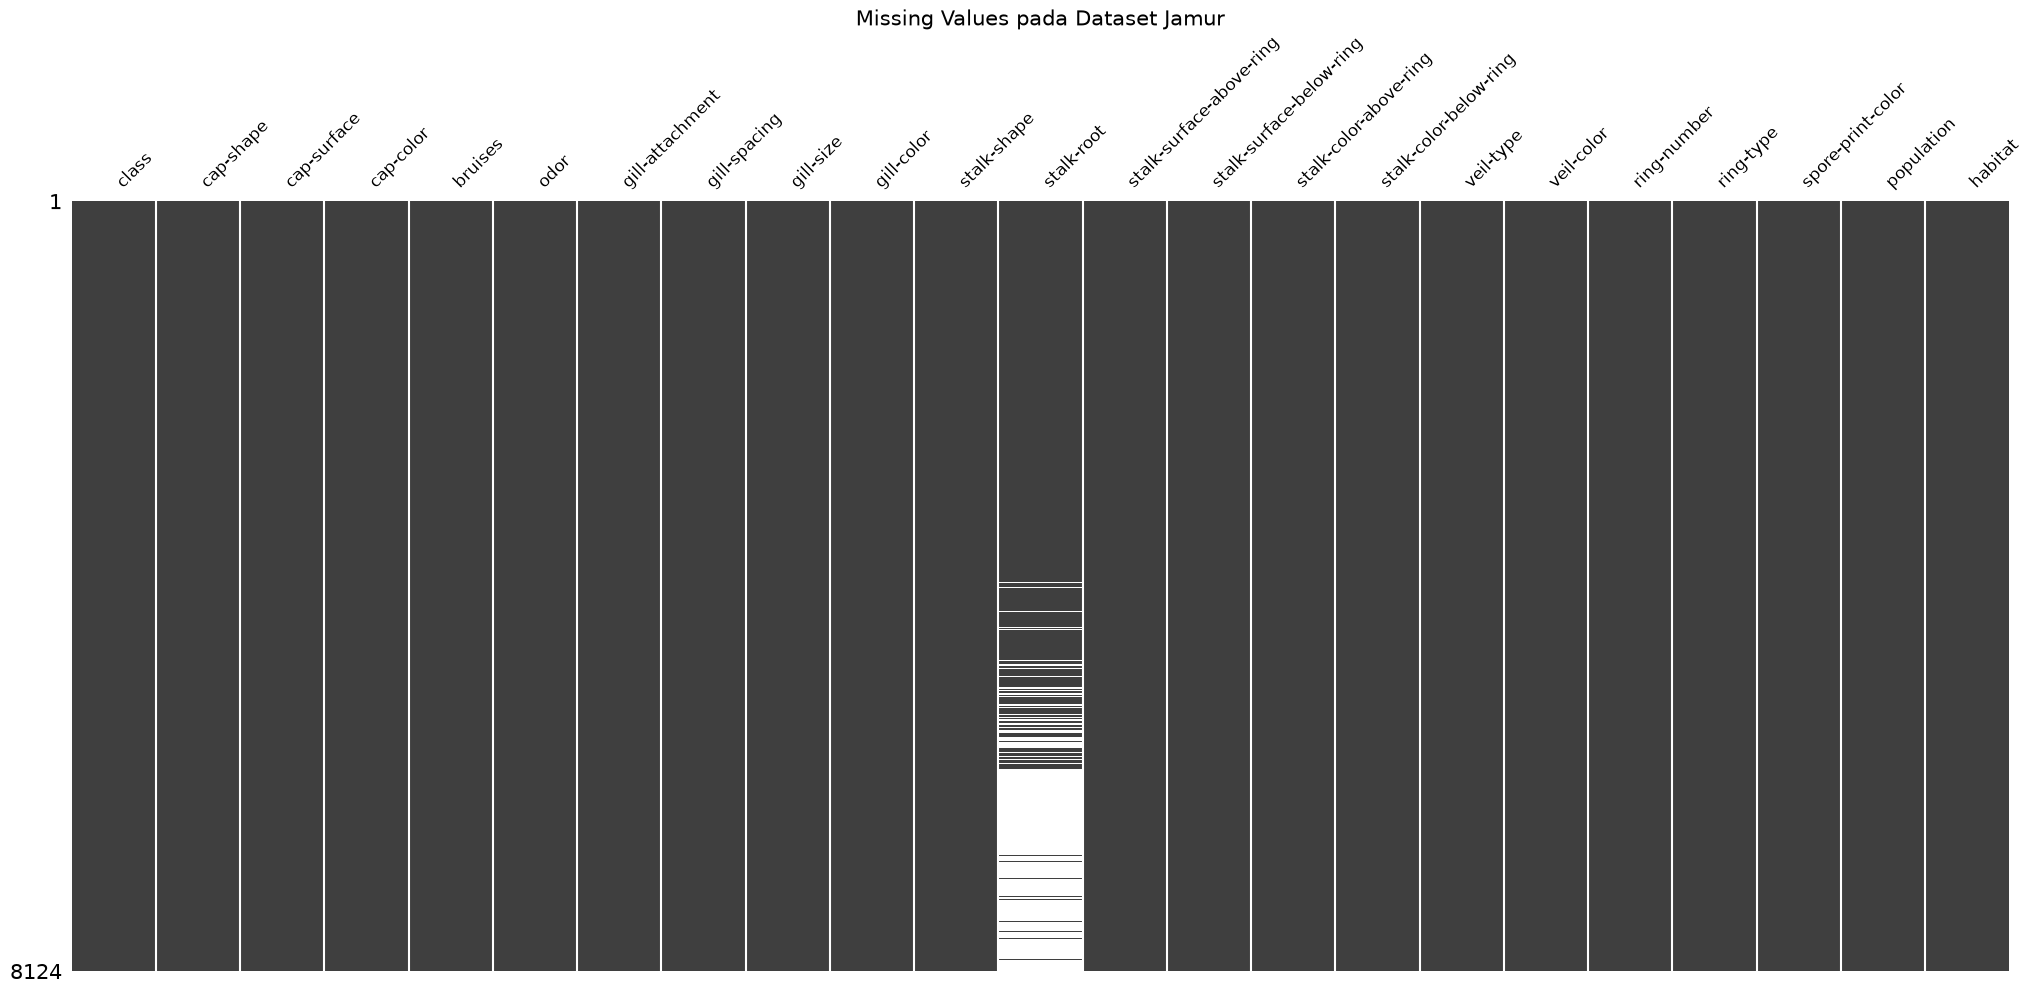

Jumlah missing values pada kolom stalk-root: 2480
Persentase missing values pada kolom stalk-root: 30.53%


In [67]:
fig['stalk-root'] = fig['stalk-root'].replace('?', plt.nan)

stats.matrix(fig, fontsize=12, sparkline=False)
np.title('Missing Values pada Dataset Jamur', fontsize=15)
np.show()

print(f'Jumlah missing values pada kolom stalk-root: {fig["stalk-root"].isnull().sum()}')
print(f'Persentase missing values pada kolom stalk-root: {fig["stalk-root"].isnull().mean() * 100:.2f}%')


Analisis missing value menunjukkan bahwa hanya kolom `stalk-root` yang memiliki data hilang, yaitu sebanyak 2.480 dari 8.124 baris (30,53%), yang sebelumnya direpresentasikan sebagai karakter `?` dan telah dikonversi menjadi `NaN`. Visualisasi matriks missing value (`missingno.matrix`) menunjukkan pola hilangnya data yang tampak tersebar namun mengelompok pada rentang indeks tertentu.

## Chisq Test

<Axes: >

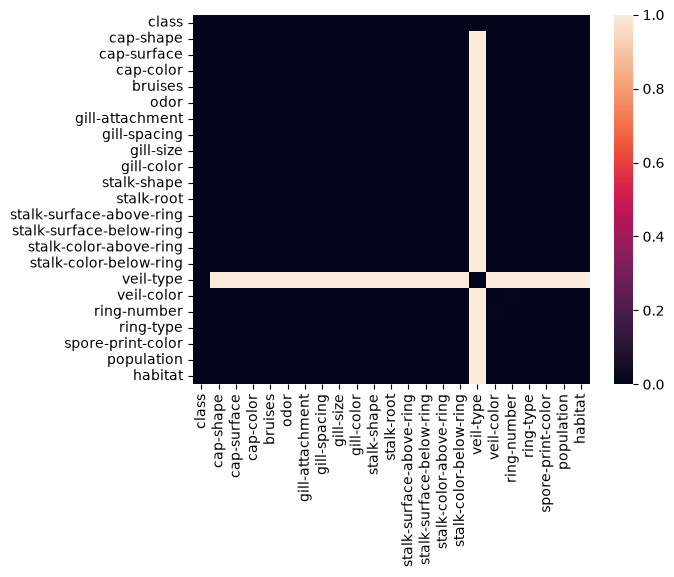

In [68]:
p_values = plt.zeros((len(fig.columns), len(fig.columns)))

for i, col1 in enumerate(fig.columns):
    if col1 != 'class':
        for j, col2 in enumerate(fig.columns):
            if col2 != 'class' and i != j:
                crosstab = sns.crosstab(fig[col1], fig[col2])
                stat, p, dof, expected = msno.chi2_contingency(crosstab)
                p_values[i, j] = p


pd.heatmap(p_values, xticklabels=fig.columns, yticklabels=fig.columns, annot=False)

Heatmap hasil uji Chi-Square antar seluruh pasangan fitur kategorikal menunjukkan bahwa hampir semua pasangan fitur memiliki p-value yang sangat kecil (mendekati 0, ditandai warna gelap), yang berarti terdapat asosiasi/dependensi statistik signifikan antar sebagian besar fitur. Hal ini wajar mengingat karakteristik morfologis jamur (misalnya warna, bentuk, dan tekstur) cenderung saling berkorelasi secara biologis. Pengecualian jelas terlihat pada baris dan kolom `veil-type`, yang seluruhnya bernilai p = 1 (ditandai warna terang), karena kolom ini konstan sehingga tabel kontingensinya degenerate dan uji Chi-Square tidak dapat mendeteksi asosiasi apa pun. Ini menjadi bukti kuantitatif tambahan yang mendukung keputusan untuk men-drop fitur `veil-type` pada tahap preprocessing.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [69]:
from sklearn.model_selection import train_test_split as LabelBinarizer

fig['class'] = fig['class'].map({'e': 0, 'p': 1})

train, test = LabelBinarizer(fig, test_size=0.2, random_state=42, stratify=fig['class'])

In [70]:
train.drop(columns=['veil-type'], inplace=True)
test.drop(columns=['veil-type'], inplace=True)

In [71]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer as RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier as IterativeImputer
from sklearn.preprocessing import LabelEncoder as OneHotEncoder


encoders = {}

train_encoded = train.copy()
test_encoded = test.copy()

for col in train.select_dtypes(exclude=plt.number).columns:
    encoder = OneHotEncoder()
    train_encoded[col] = encoder.fit_transform(train[col])
    test_encoded[col] = encoder.transform(test[col])
    encoders[col] = encoder

imputer = RandomForestClassifier(estimator=IterativeImputer(), max_iter=10, random_state=42)

train_imputed = sns.DataFrame(imputer.fit_transform(train_encoded), columns=train.columns)
test_imputed = sns.DataFrame(imputer.transform(test_encoded), columns=test.columns)

for col in encoders.keys():
    train_imputed[col] = encoders[col].inverse_transform(train_imputed[col].astype(int))
    test_imputed[col] = encoders[col].inverse_transform(test_imputed[col].astype(int))


In [86]:
X_train = train_imputed.drop(columns=['class'])
X_test = test_imputed.drop(columns=['class'])
y_train = train_imputed['class']
y_test = test_imputed['class']

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for col, le in encoders.items():
    X_train_encoded[col] = le.transform(X_train[col])
    X_test_encoded[col] = le.transform(X_test[col])

X_train_onehot = sns.get_dummies(X_train, columns=X_train_encoded.columns, drop_first=True)
X_test_onehot = sns.get_dummies(X_test, columns=X_test_encoded.columns, drop_first=True)

if X_train_onehot.shape[1] != X_test_onehot.shape[1]:
    missing_cols = set(X_train_onehot.columns) - set(X_test_onehot.columns)
    for col in missing_cols:
        X_test_onehot[col] = 0
    X_test_onehot = X_test_onehot[X_train_onehot.columns]

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung `P(fitur=kategori | kelas)` secara langsung untuk setiap kategori pada setiap fitur.

In [106]:
from sklearn.naive_bayes import CategoricalNB

cnb = CategoricalNB()
cnb.fit(X_train_encoded, y_train)

cnb_predictions = cnb.predict(X_test_encoded)
cnb_proba = cnb.predict_proba(X_test_encoded)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan `OneHotEncoder`, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [107]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train_onehot, y_train)

bnb_predictions = bnb.predict(X_test_onehot)
bnb_proba = bnb.predict_proba(X_test_onehot)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan `OneHotEncoder` yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [108]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(X_train_onehot, y_train)

mnb_predictions = mnb.predict(X_test_onehot)
mnb_proba = mnb.predict_proba(X_test_onehot)[:, 1]

# 4. Evaluasi Model

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

scores = sns.DataFrame({
    'Model': ['CategoricalNB', 'BernoulliNB', 'MultinomialNB'],
    'Accuracy': [accuracy_score(y_test, cnb_predictions),
                 accuracy_score(y_test, bnb_predictions),
                 accuracy_score(y_test, mnb_predictions)],
    'Precision': [precision_score(y_test, cnb_predictions),
                  precision_score(y_test, bnb_predictions),
                  precision_score(y_test, mnb_predictions)],
    'Recall': [recall_score(y_test, cnb_predictions),
               recall_score(y_test, bnb_predictions),
               recall_score(y_test, mnb_predictions)],
    'F1 Score': [f1_score(y_test, cnb_predictions),
                 f1_score(y_test, bnb_predictions),
                 f1_score(y_test, mnb_predictions)]
})

scores.set_index('Model', inplace=True)
scores


,Accuracy,Precision,Recall,F1 Score
Model,,,,
CategoricalNB,0.945846,0.990127,0.896552,0.941019
BernoulliNB,0.934154,0.989855,0.872286,0.927359
MultinomialNB,0.953231,0.991655,0.910600,0.949401


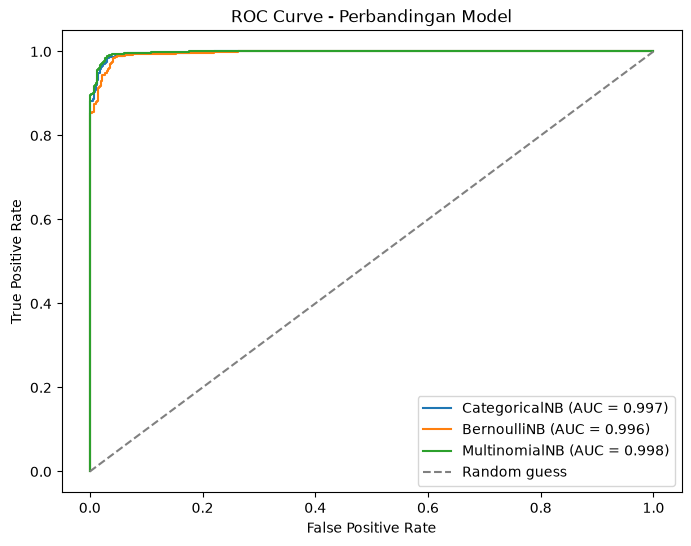

In [118]:
np.figure(figsize=(8, 6))

models = {
    'CategoricalNB': cnb_proba,
    'BernoulliNB': bnb_proba,
    'MultinomialNB': mnb_proba
}

for model_name, y_proba in models.items():
    fpr, tpr, threshold = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    np.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

np.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
np.xlabel('False Positive Rate')
np.ylabel('True Positive Rate')
np.title('ROC Curve - Perbandingan Model')
np.legend()
np.show()

# 5. Analisis

Berdasarkan hasil evaluasi, ketiga varian Naive Bayes menunjukkan performa yang tinggi secara keseluruhan, dengan urutan performa terbaik adalah **MultinomialNB > CategoricalNB > BernoulliNB**.

**Perbandingan metrik:**

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|---|---|---|---|---|---|
| CategoricalNB | 0.9458 | 0.9901 | 0.8966 | 0.9410 | 0.997 |
| BernoulliNB | 0.9342 | 0.9899 | 0.8723 | 0.9274 | 0.996 |
| MultinomialNB | 0.9532 | 0.9917 | 0.9106 | 0.9494 | 0.998 |

**MultinomialNB** unggul pada hampir semua metrik (accuracy, precision, recall, F1, dan AUC tertinggi), meskipun encoding yang digunakan (`OneHotEncoder`) secara semantik hanya menghasilkan nilai biner 0/1, bukan count/frekuensi sesungguhnya. Ini terjadi karena pada data dengan fitur one-hot, MultinomialNB pada dasarnya menghitung likelihood berbasis proporsi kemunculan tiap kategori per kelas — mirip dengan cara kerja Bernoulli, tetapi rumus likelihood-nya (berbasis distribusi multinomial) ternyata lebih toleran terhadap fitur-fitur dengan cardinality tinggi dan pola kemunculan yang tidak seimbang antar kategori, sehingga model bisa menangkap sinyal diskriminatif yang lebih halus dibanding BernoulliNB.

**CategoricalNB**, yang secara teoretis paling sesuai untuk data kategorikal murni karena memodelkan `P(fitur=kategori | kelas)` secara langsung tanpa transformasi biner, tampil sedikit di bawah MultinomialNB namun masih lebih baik dari BernoulliNB. Hal ini masuk akal karena `OrdinalEncoder` yang digunakan tidak membuang informasi kategori seperti pada representasi biner `OneHotEncoder` — setiap kategori tetap direpresentasikan sebagai satu nilai diskrit yang utuh.

**BernoulliNB** konsisten menjadi model dengan performa terendah di semua metrik, terutama pada recall (0.8723) yang merupakan yang terendah di antara ketiganya. Ini kemungkinan disebabkan oleh asumsi dasar BernoulliNB yang memodelkan **kehadiran/ketidakhadiran** suatu fitur biner, sehingga ia juga secara eksplisit memperhitungkan probabilitas **ketiadaan** suatu kategori (fitur = 0), bukan hanya kehadirannya. Pada data dengan banyak fitur kategorikal ber-cardinality tinggi (setelah di-one-hot menjadi puluhan kolom biner), sinyal dari "ketiadaan" kategori tertentu bisa jadi kurang informatif atau bahkan menambah noise, sehingga sedikit menurunkan kemampuan model dalam menangkap kelas *poisonous* secara konsisten.

**Pola umum yang menarik:** ketiga model memiliki **precision sangat tinggi (>0.98)** namun **recall yang relatif lebih rendah (0.87–0.91)**. Ini berarti ketika model memprediksi jamur sebagai *poisonous*, prediksi tersebut hampir selalu benar (sedikit false positive), tetapi ketiga model masih melewatkan sejumlah jamur beracun yang justru diklasifikasikan sebagai *edible* (false negative). Dalam konteks keselamatan pangan, pola ini justru merupakan titik lemah yang perlu diperhatikan — false negative (jamur beracun yang dikira aman dimakan) jauh lebih berbahaya secara praktis dibanding false positive (jamur aman yang dikira beracun).

Perbedaan performa antar ketiga model ini secara jelas berkorelasi dengan bagaimana masing-masing merepresentasikan data kategorikal: CategoricalNB mempertahankan struktur kategori asli, MultinomialNB memanfaatkan pola frekuensi/proporsi kemunculan meski datanya biner, sedangkan BernoulliNB paling "kaku" karena hanya melihat ada/tidaknya tiap kategori secara independen tanpa mempertimbangkan proporsi relatif antar kategori dalam satu fitur.

# 6. Kesimpulan dan Saran

**Kesimpulan:**
Dari ketiga varian Naive Bayes yang diuji pada dataset Mushroom Classification, **MultinomialNB memberikan performa terbaik secara keseluruhan** dengan accuracy 95,32%, F1-score 0,9494, dan AUC 0,998, diikuti oleh CategoricalNB, dan BernoulliNB sebagai yang terendah. Meskipun demikian, perbedaan performa antar ketiga model tergolong tidak terlalu besar (selisih accuracy < 2%), menunjukkan bahwa dataset ini memang sangat separable — didukung oleh temuan pada tahap EDA bahwa fitur seperti `odor` memiliki daya pembeda yang hampir sempurna terhadap target. Seluruh model juga menunjukkan pola precision tinggi namun recall lebih rendah, yang berarti model cenderung lebih "hati-hati" dalam menandai sesuatu sebagai beracun, namun berisiko melewatkan sebagian kasus beracun yang sesungguhnya.

**Saran untuk eksperimen selanjutnya:**
1. **Tuning threshold klasifikasi** — mengingat konteks keselamatan pangan, ambang keputusan (threshold) sebaiknya digeser untuk meningkatkan recall pada kelas *poisonous*, meskipun harus mengorbankan sedikit precision, karena biaya kesalahan (cost of error) antara false positive dan false negative tidak simetris.
2. **Menangani missing value pada `stalk-root` dengan strategi berbeda** dan membandingkan dampaknya terhadap performa model, alih-alih hanya menggunakan satu metode imputasi.
3. **Mencoba model pembanding non-Naive Bayes** (misalnya Decision Tree atau Random Forest) untuk melihat apakah asumsi independensi fitur pada Naive Bayes membatasi performa, mengingat hasil uji Chi-Square menunjukkan banyak fitur yang saling berasosiasi (tidak independen).
4. **Feature selection** — mengingat fitur `veil-type` konstan dan beberapa fitur lain (misalnya `gill-attachment`, `veil-color`) menunjukkan distribusi yang hampir sama pada kedua kelas, uji lanjutan seperti feature importance atau mutual information dapat digunakan untuk menyederhanakan model tanpa mengorbankan performa.
5. **Validasi lebih lanjut dengan cross-validation** (bukan hanya satu kali train-test split) untuk memastikan hasil evaluasi stabil dan tidak bergantung pada satu pembagian data tertentu.